In [16]:
# %%
# CA 49 Roseland — Point 1 pipeline (Python)
# Requires: geopandas, pandas, shapely, requests, matplotlib, contextily (optional for basemaps)

import os
import io
import zipfile
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import urllib.parse
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
import math

In [24]:
CA_PATH = "Community_Areas.zip"

ca = gpd.read_file(f"zip://{CA_PATH}")

# Project to  WGS84 
ca = ca.to_crs(4326)

print("Columns:", ca.columns.tolist())
print("Rows:", len(ca))
print(" Zip read successfully")

# Common name field is 'community' or 'communityA' depending on vintage; id is 'area_numbe'/'area_num_1'
if 'area_num_1' in ca.columns:
    ca['area_num'] = ca['area_num_1'].astype(int)
elif 'area_numbe' in ca.columns:
    ca['area_num'] = ca['area_numbe'].astype(int)
else:
    raise ValueError("Couldn't find area number field in CA shapefile")

roseland = ca.loc[ca['area_num'] == 49].copy()
assert len(roseland) == 1, "Roseland (CA 49) not found or duplicated"




Columns: ['area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len', 'geometry']
Rows: 77
 Zip read successfully


In [22]:
import requests, zipfile, io, geopandas as gpd, tempfile, os

def read_zipped_shapefile(url: str) -> gpd.GeoDataFrame:
    """
    Download a ZIP shapefile from a URL, save it temporarily,
    and load it as a GeoDataFrame.
    """
    print(f"  Downloading shapefile from {url} ...")
    r = requests.get(url)
    r.raise_for_status()

    # Create a temporary directory to store the zip
    with tempfile.TemporaryDirectory() as tmpdir:
        zip_path = os.path.join(tmpdir, "temp.zip")
        with open(zip_path, "wb") as f:
            f.write(r.content)

        # Read directly from the saved zip
        gdf = gpd.read_file(f"zip://{zip_path}")
        print(f" Loaded shapefile with {len(gdf)} rows and {len(gdf.columns)} columns.")
        return gdf



In [ ]:
# ---------------------------
# 1) Get Cook County block groups TIGER/Line and intersect with Roseland
# ---------------------------
TIGER_BG_URL = "https://www2.census.gov/geo/tiger/TIGER2021/BG/tl_2021_17_bg.zip"

bg_il = read_zipped_shapefile(TIGER_BG_URL).to_crs(4326)
bg_il['COUNTYFP'] = bg_il['COUNTYFP'].astype(str)
bg_cook = bg_il[bg_il['COUNTYFP'] == '031'].copy()

bg_roseland = gpd.overlay(bg_cook, roseland[['geometry']], how='intersection')
bg_ids = bg_roseland['GEOID'].unique().tolist()
print(f"Roseland BG count: {len(bg_ids)}")

# (Optional) Save so you can reuse
bg_roseland.to_file("Roseland-CA49/roseland_blockgroups.geojson", driver="GeoJSON")

 Loaded shapefile with 9898 rows and 13 columns.
Roseland BG count: 66


In [ ]:
import time 
import requests
import pandas as pd
import time

def fetch_acs_roesland(year: int, variables: list[str], bg_ids: list[str]) -> pd.DataFrame:
    base_url = f"https://api.census.gov/data/{year}/acs/acs5"
    all_data = []

    for geoid in bg_ids:
        state = geoid[:2]
        county = geoid[2:5]
        tract = geoid[5:11]
        bg = geoid[11:]
        var_clause = ",".join(variables)
        params = {
            "get": var_clause + ",state,county,tract,block group",
            "for": f"block group:{bg}",
            "in": f"state:{state} county:{county} tract:{tract}",
            "key": CENSUS_API_KEY,
        }
        r = requests.get(base_url, params=params)
        if r.status_code == 204 or not r.text.strip():
            print(f" {geoid} returned 204 or empty — skipping")
            continue
        if r.status_code != 200:
            print(f" {geoid} returned {r.status_code}: {r.text[:100]}")
            continue
        try:
            rows = r.json()
        except Exception:
            print(f" {geoid} could not decode JSON — skipping")
            continue
        df = pd.DataFrame(rows[1:], columns=rows[0])
        for v in variables:
            df[v] = pd.to_numeric(df[v], errors="coerce")
        df["GEOID"] = geoid
        all_data.append(df)
        time.sleep(0.3)  # respect API rate limits

    if not all_data:
        raise ValueError("No data retrieved for any block groups.")
    df_all = pd.concat(all_data, ignore_index=True)
    print(f" Retrieved {len(df_all)} block groups for {year}")
    return df_all


In [ ]:
print(bg_ids[:5])
170314905001
170314902003

['170314905001', '170314907001', '170314907002', '170314907003', '170314908001']


170314905001

In [ ]:
import requests
import pandas as pd
import time



ACS_YEARS = [2013, 2014,2015,2016,2017,2018, 2019, 2020, 2021, 2022, 2023]
ACS_VARS = {
    'total_pop': 'B01003_001E',
    'median_age': 'B01002_001E',
    'race_total': 'B02001_001E',
    'race_black': 'B02001_003E',
    'hisp_total': 'B03003_001E',
    'hisp': 'B03003_003E',
    'med_hh_income': 'B19013_001E',
    'pov_universe': 'B17001_001E',
    'pov_below': 'B17001_002E',
    'lf_civilian': 'B23025_003E',
    'unemployed': 'B23025_005E',
    'occ_units': 'B25003_001E',
    'owner_occ': 'B25003_002E',
    'renter_occ': 'B25003_003E',
    'units_total': 'B25002_001E',
    'units_vacant': 'B25002_003E',
}

def fetch_acs_roesland(year: int, variables: list[str], bg_ids: list[str]) -> pd.DataFrame:
    """
    Descarga datos ACS 5-year para una lista de GEOIDs de block groups.
    """
    base_url = f"https://api.census.gov/data/{year}/acs/acs5"
    all_data = []

    for geoid in bg_ids:
        state = geoid[:2]
        county = geoid[2:5]
        tract = geoid[5:11]
        bg = geoid[11:]

        var_clause = ",".join(["NAME"] + variables)

        params = {
            "get": var_clause,
            "for": f"block group:{bg or '*'}",
            "in": f"state:{state} county:{county} tract:{tract}",
            "key": CENSUS_API_KEY,
        }

        try:
            r = requests.get(base_url, params=params)
        except Exception as e:
            print(f" Error de conexión en {geoid}: {e}")
            continue

        if r.status_code != 200:
            print(f" {geoid} → Error {r.status_code}: {r.text[:120]}")
            continue

        try:
            data = r.json()
        except Exception:
            print(f" {geoid} → respuesta no JSON válida")
            continue

        if len(data) < 2:
            print(f" {geoid} → respuesta vacía")
            continue

        df = pd.DataFrame(data[1:], columns=data[0])
        df["GEOID"] = geoid

       
        for v in variables:
            df[v] = pd.to_numeric(df[v], errors="coerce")

        all_data.append(df)
        time.sleep(0.3) 

    if not all_data:
        raise ValueError(f"No se recuperaron datos para ningún block group en {year}")

    df_all = pd.concat(all_data, ignore_index=True)
    print(f" {len(df_all)} filas recuperadas para {year}")
    return df_all


In [ ]:
variables = list(ACS_VARS.values())
dfs = []

for year in ACS_YEARS:
    print(f"\n🔹 Downloading data from {year}...")
    df_year = fetch_acs_roesland(year, variables, bg_ids)
    df_year["year"] = year  
    dfs.append(df_year)


df_all_years = pd.concat(dfs, ignore_index=True)

print(" Combined data for all years:", df_all_years.shape)
print(df_all_years.head())


df_all_years.to_csv("Roseland-CA49/acs_blockgroups_all_years2013-2023.csv", index=False)



🔹 Descargando datos para 2013...
⚠️  170314902003 → Error 204: 
⚠️  170314902002 → Error 204: 
⚠️  170314902001 → Error 204: 
✅ 63 filas recuperadas para 2013

🔹 Descargando datos para 2014...
⚠️  170314902003 → Error 204: 
⚠️  170314902002 → Error 204: 
⚠️  170314902001 → Error 204: 
✅ 63 filas recuperadas para 2014

🔹 Descargando datos para 2015...
⚠️  170314902003 → Error 204: 
⚠️  170314902002 → Error 204: 
⚠️  170314902001 → Error 204: 
✅ 63 filas recuperadas para 2015

🔹 Descargando datos para 2016...
⚠️  170314902003 → Error 204: 
⚠️  170314902002 → Error 204: 
⚠️  170314902001 → Error 204: 
✅ 63 filas recuperadas para 2016

🔹 Descargando datos para 2017...
⚠️  170314902003 → Error 204: 
⚠️  170314902002 → Error 204: 
⚠️  170314902001 → Error 204: 
✅ 63 filas recuperadas para 2017

🔹 Descargando datos para 2018...
⚠️  170314902003 → Error 204: 
⚠️  170314902002 → Error 204: 
⚠️  170314902001 → Error 204: 
✅ 63 filas recuperadas para 2018

🔹 Descargando datos para 2019...
⚠️  17

# PLOTS

In [2]:
import pandas as pd

df = pd.read_csv("Roseland-CA49/acs_blockgroups_all_years2010-2023.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(705, 23)
['NAME', 'B01003_001E', 'B01002_001E', 'B02001_001E', 'B02001_003E', 'B03003_001E', 'B03003_003E', 'B19013_001E', 'B17001_001E', 'B17001_002E', 'B23025_003E', 'B23025_005E', 'B25003_001E', 'B25003_002E', 'B25003_003E', 'B25002_001E', 'B25002_003E', 'state', 'county', 'tract', 'block group', 'GEOID', 'year']


,NAME,B01003_001E,B01002_001E,B02001_001E,B02001_003E,B03003_001E,B03003_003E,B19013_001E,B17001_001E,B17001_002E,...,B25003_002E,B25003_003E,B25002_001E,B25002_003E,state,county,tract,block group,GEOID,year
0,"Block Group 1, Census Tract 4912, Cook County,...",1366,30.2,1366,1353,1366,0,44750.0,NaN,NaN,...,164,143,344,37,17,31,491200,1,170314912001,2013
1,"Block Group 2, Census Tract 4912, Cook County,...",625,43.3,625,625,625,21,38393.0,NaN,NaN,...,175,51,226,0,17,31,491200,2,170314912002,2013
2,"Block Group 3, Census Tract 4912, Cook County,...",751,45.4,751,747,751,0,24432.0,NaN,NaN,...,165,99,264,0,17,31,491200,3,170314912003,2013
3,"Block Group 2, Census Tract 4913, Cook County,...",610,41.1,610,590,610,6,46992.0,NaN,NaN,...,72,67,173,34,17,31,491300,2,170314913002,2013
4,"Block Group 3, Census Tract 4913, Cook County,...",751,29.8,751,737,751,0,48304.0,NaN,NaN,...,62,157,278,59,17,31,491300,3,170314913003,2013


Data cleaning

In [3]:
import numpy as np

# Definir las columnas numéricas relevantes
cols = [
    "B01003_001E",  # total population
    "B19013_001E",  # median income
    "B01002_001E",  # median age
    "B23025_005E",  # unemployed
    "B23025_003E",  # labor force
    "B25003_002E",  # owner occupied
    "B25003_001E",  # total occupied
    "B25002_003E",  # vacant units
    "B25002_001E",  # total units
]

# Reemplazar ceros o negativos por NaN
for c in cols:
    df.loc[df[c] <= 0, c] = np.nan
    

for c in ["B19013_001E", "B01003_001E"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 3*iqr, q3 + 3*iqr
    df.loc[(df[c] < lower) | (df[c] > upper), c] = np.nan





In [4]:
[x for x in df.columns if 'B02001' in x or 'B03003' in x]
df['pct_black'] = df['B02001_003E'] / df['B02001_001E']


In [5]:
def weighted_avg(values, weights):
    mask = (~values.isna()) & (~weights.isna())
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

ca_ts = (
    df.groupby("year")
    .apply(lambda g: pd.Series({
        "total_pop": g["B01003_001E"].sum(),
        "median_income": weighted_avg(g["B19013_001E"], g["B01003_001E"]),
        "median_age": weighted_avg(g["B01002_001E"], g["B01003_001E"]),
        "pct_black": weighted_avg(g["pct_black"], g["B01003_001E"]),
        "unemployed": g["B23025_005E"].sum(),
        "labor_force": g["B23025_003E"].sum(),
        "owner_occupied": g["B25003_002E"].sum(),
        "total_occupied": g["B25003_001E"].sum(),
        "vacant_units": g["B25002_003E"].sum(),
        "total_units": g["B25002_001E"].sum(),
    }))
    .reset_index()
)

ca_ts["unemp_rate"] = ca_ts["unemployed"] / ca_ts["labor_force"]
ca_ts["owner_share"] = ca_ts["owner_occupied"] / ca_ts["total_occupied"]
ca_ts["vacancy_rate"] = ca_ts["vacant_units"] / ca_ts["total_units"]


ca_ts.head()


/var/folders/kr/b0lqv51s11jgmpqg8fv7t0dw0000gn/T/ipykernel_35379/1392738524.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,year,total_pop,median_income,median_age,pct_black,unemployed,labor_force,owner_occupied,total_occupied,vacant_units,total_units,unemp_rate,owner_share,vacancy_rate
0,2013,61568.0,42157.642899,38.646583,0.954652,6394.0,27611.0,12266.0,22166.0,4342.0,26508.0,0.231574,0.553370,0.163800
1,2014,63355.0,39724.471881,38.641026,0.955931,6706.0,27321.0,12100.0,21838.0,4252.0,26090.0,0.245452,0.554080,0.162974
2,2015,60291.0,39278.541960,39.014390,0.945365,6386.0,26784.0,11760.0,21229.0,4541.0,25770.0,0.238426,0.553959,0.176213
3,2016,60768.0,39061.870223,39.598336,0.950105,6893.0,27499.0,12004.0,21556.0,4574.0,26130.0,0.250664,0.556875,0.175048
4,2017,60623.0,40919.901420,39.901867,0.951174,6489.0,28047.0,11978.0,21537.0,4508.0,26045.0,0.231362,0.556159,0.173085


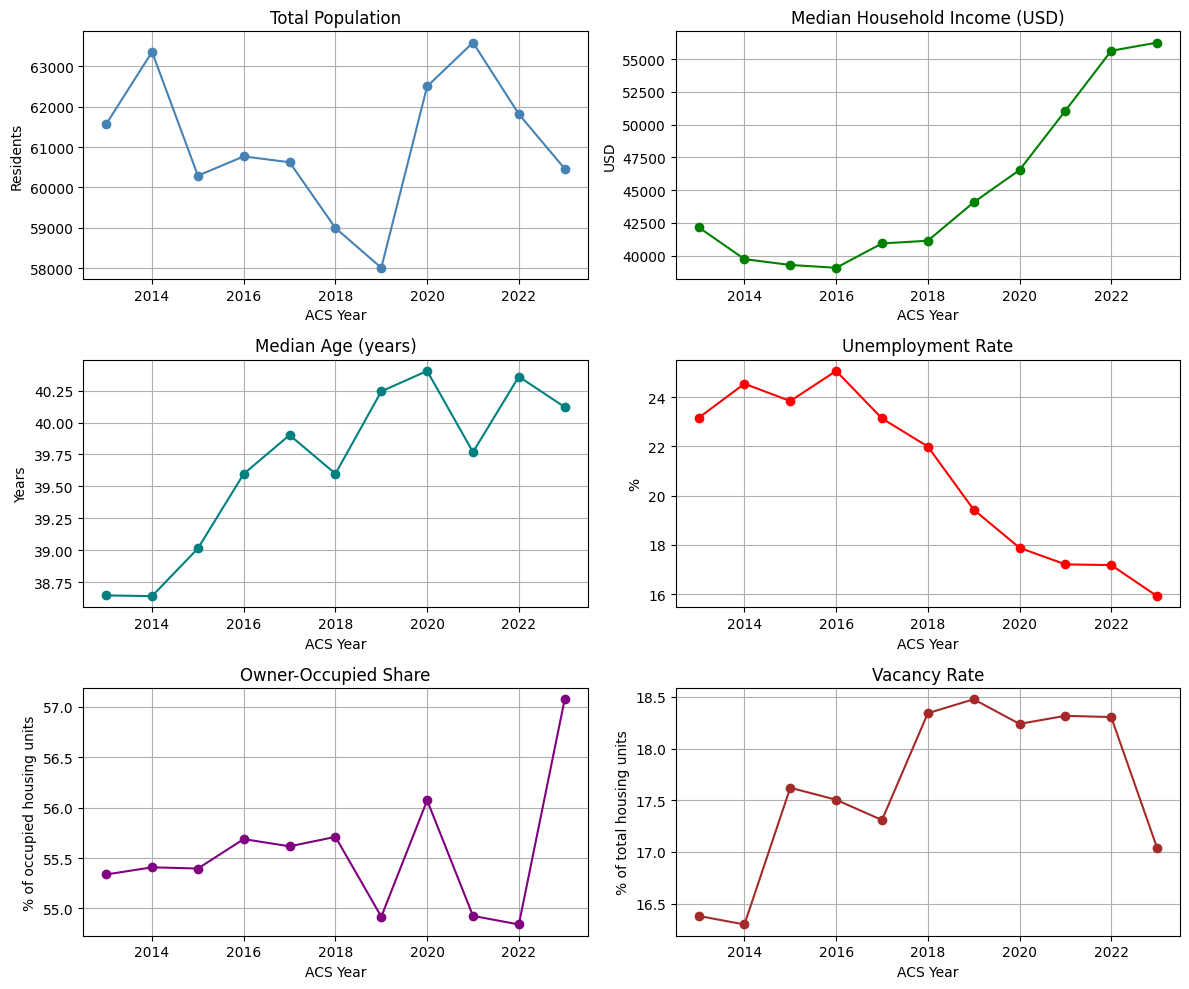

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12,10))
axes = axes.flatten()

# 1. Population
axes[0].plot(ca_ts['year'], ca_ts['total_pop'], marker='o', color='steelblue')
axes[0].set_title('Total Population')
axes[0].set_ylabel('Residents')

# 2. Median household income
axes[1].plot(ca_ts['year'], ca_ts['median_income'], marker='o', color='green')
axes[1].set_title('Median Household Income (USD)')
axes[1].set_ylabel('USD')

# 3. Median age
axes[2].plot(ca_ts['year'], ca_ts['median_age'], marker='o', color='teal')
axes[2].set_title('Median Age (years)')
axes[2].set_ylabel('Years')

# 4. Unemployment rate
axes[3].plot(ca_ts['year'], ca_ts['unemp_rate']*100, marker='o', color='red')
axes[3].set_title('Unemployment Rate')
axes[3].set_ylabel('%')

# 5. Owner-occupied share
axes[4].plot(ca_ts['year'], ca_ts['owner_share']*100, marker='o', color='purple')
axes[4].set_title('Owner-Occupied Share')
axes[4].set_ylabel('% of occupied housing units')

# 6. Vacancy rate
axes[5].plot(ca_ts['year'], ca_ts['vacancy_rate']*100, marker='o', color='brown')
axes[5].set_title('Vacancy Rate')
axes[5].set_ylabel('% of total housing units')

for ax in axes:
    ax.set_xlabel('ACS Year')
    ax.grid(True)

plt.tight_layout()
plt.show()
fig.savefig("Roseland-CA49/roseland_trends.png", dpi=300, bbox_inches='tight')



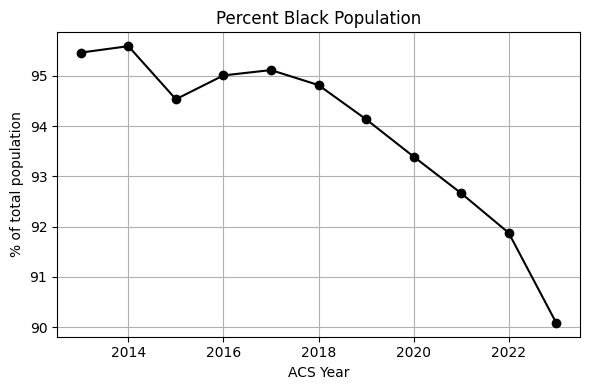

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(ca_ts['year'], ca_ts['pct_black']*100, marker='o', color='black')
ax.set_title('Percent Black Population')
ax.set_xlabel('ACS Year')
ax.set_ylabel('% of total population')
ax.grid(True)
plt.tight_layout()
plt.show()


## Economic analaysis


In [8]:
ca_ts = ca_ts[ca_ts['labor_force'] > 0]
ca_ts[['year','total_pop','labor_force','unemployed']].diff().describe()


,year,total_pop,labor_force,unemployed
count,10.0,10.000000,10.000000,10.000000
mean,1.0,-110.400000,-16.900000,-202.700000
std,0.0,2176.503475,736.905911,370.131523
min,1.0,-3064.000000,-1170.000000,-698.000000
25%,1.0,-1558.500000,-475.250000,-398.000000
50%,1.0,-564.500000,-97.000000,-280.500000
75%,1.0,930.750000,572.750000,-111.500000
max,1.0,4492.000000,1065.000000,507.000000


In [9]:
# Estimates come from ACS 5-Year Data at the block group level.
# Due to the small sample size, year-to-year variations in the series
# do not necessarily reflect real demographic changes.
ca_ts[['total_pop', 'labor_force', 'unemployed', 'median_income']] = (
    ca_ts[['total_pop', 'labor_force', 'unemployed', 'median_income']].rolling(3, center=True, min_periods=1).mean()
)


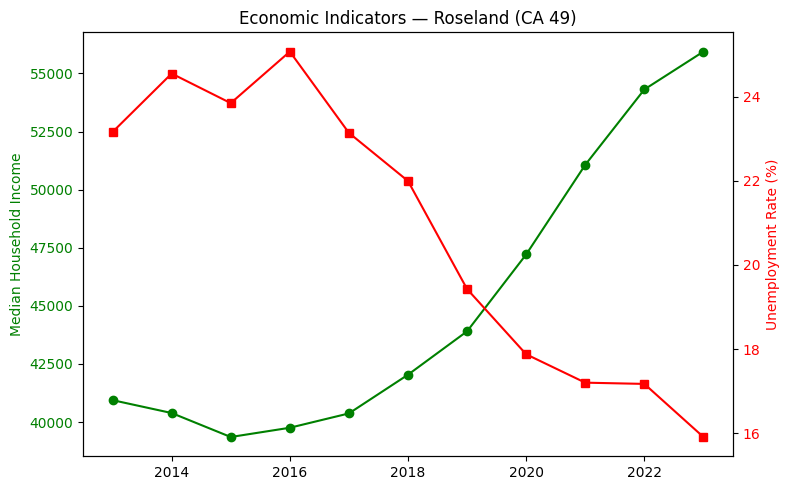

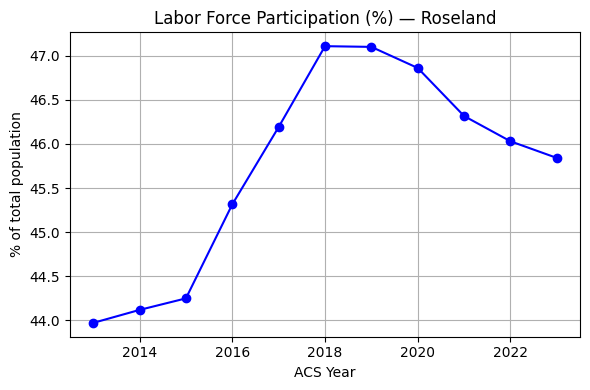

In [10]:
import matplotlib.pyplot as plt

# Calculate workforce participation (optional)
ca_ts['labor_force_participation'] = ca_ts['labor_force'] / ca_ts['total_pop']


fig, ax = plt.subplots(figsize=(8,5))
ax.plot(ca_ts['year'], ca_ts['median_income'], marker='o', color='green', label='Median Household Income (USD)')
ax.set_ylabel('Median Household Income', color='green')
ax.tick_params(axis='y', labelcolor='green')

# Twin axis for unemployment rate
ax2 = ax.twinx()
ax2.plot(ca_ts['year'], ca_ts['unemp_rate']*100, marker='s', color='red', label='Unemployment Rate')
ax2.set_ylabel('Unemployment Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Economic Indicators — Roseland (CA 49)')
plt.tight_layout()
plt.show()

# Optional: plot labor force participation
plt.figure(figsize=(6,4))
plt.plot(ca_ts['year'], ca_ts['labor_force_participation']*100, marker='o', color='blue')
plt.title('Labor Force Participation (%) — Roseland')
plt.xlabel('ACS Year')
plt.ylabel('% of total population')
plt.grid(True)
plt.tight_layout()
plt.show()


## Housing analysis 

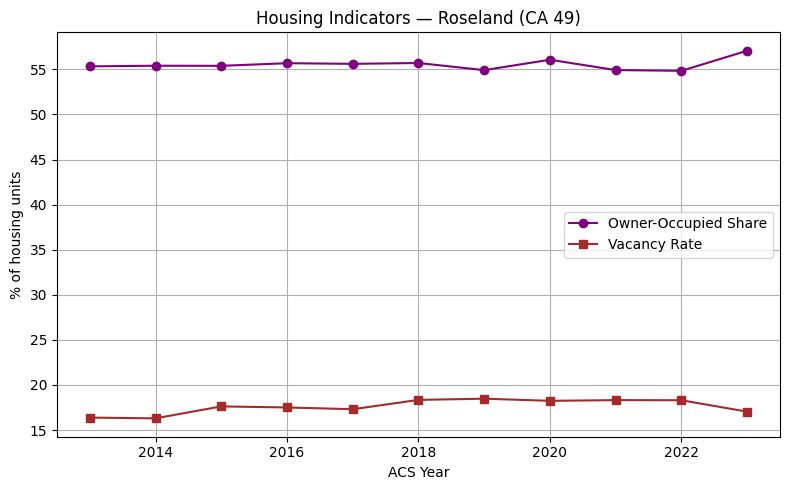

In [11]:
# If your dataset includes these variables:
# 'B25077_001E' = median home value
# 'B25064_001E' = median gross rent
if 'B25077_001E' in df.columns:
    ca_ts['median_home_value'] = df.groupby('year')['B25077_001E'].mean().values
if 'B25064_001E' in df.columns:
    ca_ts['median_rent'] = df.groupby('year')['B25064_001E'].mean().values

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(ca_ts['year'], ca_ts['owner_share']*100, marker='o', color='purple', label='Owner-Occupied Share')
ax.plot(ca_ts['year'], ca_ts['vacancy_rate']*100, marker='s', color='brown', label='Vacancy Rate')
ax.set_title('Housing Indicators — Roseland (CA 49)')
ax.set_xlabel('ACS Year')
ax.set_ylabel('% of housing units')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# If you have home value or rent data:
if 'median_home_value' in ca_ts.columns:
    plt.figure(figsize=(6,4))
    plt.plot(ca_ts['year'], ca_ts['median_home_value'], marker='o', color='darkorange')
    plt.title('Median Home Value — Roseland (CA 49)')
    plt.xlabel('ACS Year')
    plt.ylabel('USD')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Temporal change analysis

In [12]:
ca_ts[['year', 'median_income']].head(10)

,year,median_income
0,2013,40941.057390
1,2014,40386.885580
2,2015,39354.961355
3,2016,39753.437868
4,2017,40370.108780
5,2018,42035.998252
6,2019,43903.836202
7,2020,47211.953582
8,2021,51068.179637
9,2022,54311.564595


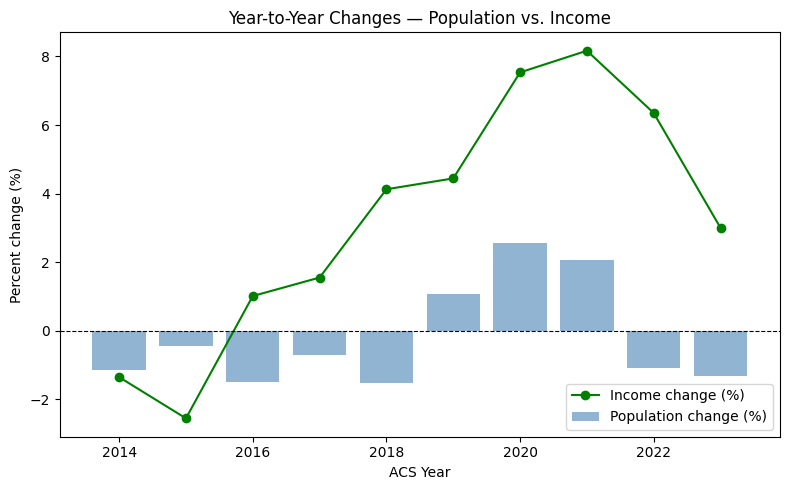

,year,total_pop_change_pct,median_income_change_pct,owner_share_change_pct,vacancy_rate_change_pct,unemp_rate_change_pct
0,2013,NaN,NaN,NaN,NaN,NaN
1,2014,-1.16,-1.35,0.13,-0.50,5.99
2,2015,-0.43,-2.56,-0.02,8.12,-2.86
3,2016,-1.48,1.01,0.53,-0.66,5.13
4,2017,-0.71,1.55,-0.13,-1.12,-7.70
5,2018,-1.53,4.13,0.17,5.98,-4.94
6,2019,1.06,4.44,-1.42,0.74,-11.67
7,2020,2.56,7.53,2.10,-1.29,-7.97
8,2021,2.07,8.17,-2.04,0.43,-3.77
9,2022,-1.09,6.35,-0.15,-0.07,-0.17


In [13]:
import numpy as np

# Compute year-to-year percent changes
for col in ['total_pop', 'median_income', 'owner_share', 'vacancy_rate', 'unemp_rate']:
    ca_ts[f'{col}_change_pct'] = ca_ts[col].pct_change() * 100

# Plot population and income change
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(ca_ts['year'], ca_ts['total_pop_change_pct'], color='steelblue', alpha=0.6, label='Population change (%)')
ax.plot(ca_ts['year'], ca_ts['median_income_change_pct'], color='green', marker='o', label='Income change (%)')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Year-to-Year Changes — Population vs. Income')
ax.set_xlabel('ACS Year')
ax.set_ylabel('Percent change (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Optional: overall summary of percent changes
ca_ts[['year'] + [c for c in ca_ts.columns if c.endswith('_change_pct')]].round(2)


## Well being index

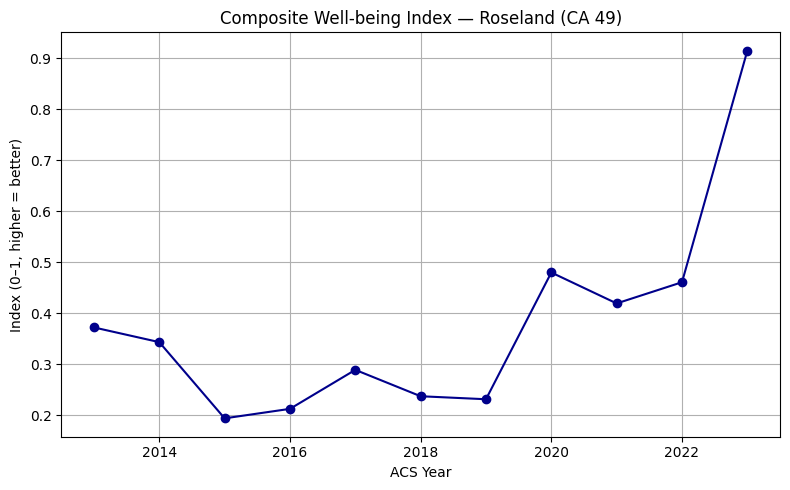

,year,wellbeing_index
0,2013,0.372
1,2014,0.343
2,2015,0.194
3,2016,0.212
4,2017,0.289
5,2018,0.237
6,2019,0.231
7,2020,0.480
8,2021,0.419
9,2022,0.461


In [14]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Select variables to include in the composite index
cols = ['median_income', 'owner_share', 'unemp_rate', 'vacancy_rate']
scaler = MinMaxScaler()

# Normalize: higher = better conditions
ca_norm = ca_ts.copy()
ca_norm[cols] = scaler.fit_transform(ca_ts[cols])

# Invert negative indicators so higher = better
ca_norm['unemp_rate'] = 1 - ca_norm['unemp_rate']
ca_norm['vacancy_rate'] = 1 - ca_norm['vacancy_rate']

# Compute the composite
ca_ts['wellbeing_index'] = (
    ca_norm['median_income'] + ca_norm['owner_share'] + 
    ca_norm['unemp_rate'] + ca_norm['vacancy_rate']
) / 4

# Plot the index
plt.figure(figsize=(8,5))
plt.plot(ca_ts['year'], ca_ts['wellbeing_index'], marker='o', color='darkblue')
plt.title('Composite Well-being Index — Roseland (CA 49)')
plt.xlabel('ACS Year')
plt.ylabel('Index (0–1, higher = better)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: inspect data
ca_ts[['year', 'wellbeing_index']].round(3)


## Comparation between 2010 and 2020

In [17]:
import requests
import pandas as pd


# Roseland tract GEOIDs
roesland_tracts = [
    "17031490100", "17031490200", "17031490300", "17031490400",
    "17031490500", "17031490600", "17031490700", "17031490800",
    "17031490900", "17031491000", "17031491100", "17031491200",
    "17031491300"
]

# helper function
def fetch_decennial(year, dataset, variables, state, county, tracts):
    url = f"https://api.census.gov/data/{year}/dec/{dataset}"
    data_list = []
    for tract in tracts:
        params = {
            "get": ",".join(["NAME"] + list(variables.values())),
            "for": f"tract:{tract[5:11]}",
            "in": f"state:{state} county:{county}",
            "key": CENSUS_API_KEY
        }
        r = requests.get(url, params=params)
        if r.status_code == 200:
            data = r.json()
            df = pd.DataFrame(data[1:], columns=data[0])
            data_list.append(df)
    if data_list:
        df_all = pd.concat(data_list, ignore_index=True)
        df_all.rename(columns={v: k for k, v in variables.items()}, inplace=True)
        for v in variables.keys():
            df_all[v] = pd.to_numeric(df_all[v], errors="coerce")
        return df_all
    else:
        return pd.DataFrame()

# 2010 SF1 variables
vars_2010 = {
    "pop_2010": "P001001",
    "white_2010": "P003002",
    "black_2010": "P003003",
    "asian_2010": "P003005",
    "hisp_2010": "P004003",
}

# 2020 PL variables
vars_2020 = {
    "pop_2020": "P1_001N",
    "white_2020": "P1_003N",
    "black_2020": "P1_004N",
    "asian_2020": "P1_006N",
    "hisp_2020": "P2_002N",
}

# fetch data
df2010 = fetch_decennial(2010, "sf1", vars_2010, state="17", county="031", tracts=roesland_tracts)
df2020 = fetch_decennial(2020, "pl", vars_2020, state="17", county="031", tracts=roesland_tracts)

# merge and compute change
df = pd.merge(
    df2010[["tract"] + list(vars_2010.keys())],
    df2020[["tract"] + list(vars_2020.keys())],
    on="tract"
)

df["pop_change"] = df["pop_2020"] - df["pop_2010"]
df["pct_change"] = (df["pop_change"] / df["pop_2010"]) * 100

# racial composition
for race in ["white", "black", "asian", "hisp"]:
    df[f"{race}_pct_2010"] = df[f"{race}_2010"] / df["pop_2010"] * 100
    df[f"{race}_pct_2020"] = df[f"{race}_2020"] / df["pop_2020"] * 100
    df[f"{race}_pct_change"] = df[f"{race}_pct_2020"] - df[f"{race}_pct_2010"]

df = df.sort_values("pct_change", ascending=False)
print(df.head(10))

# Optional: export
df.to_csv("Roseland-CA49/Roseland_Chicago_Decennial_2010_2020.csv", index=False)
print(" Saved: Roseland_Chicago_Decennial_2010_2020.csv")


KeyboardInterrupt: 

   Year  Total Population  White (%)  Black (%)  Asian (%)  Hispanic (%)
0  2010           25987.0   0.661869  97.537230   0.080810      1.073614
1  2020           21524.0   0.998885  94.652481   0.144025      2.666791


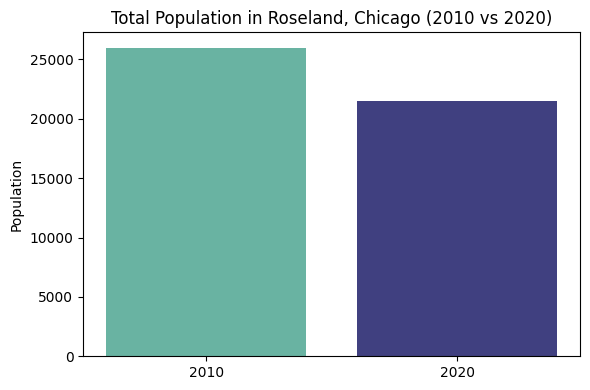

 Roseland Total Population 2010: 25,987.0
 Roseland Total Population 2020: 21,524.0
 Change: -4,463.0 people (-17.17%)


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# If you already have the tract-level CSV
df = pd.read_csv("Roseland-CA49/Roseland_Chicago_Decennial_2010_2020.csv")

# Aggregate all Roseland tracts into one total
agg = df.sum(numeric_only=True)

# Compute shares
agg_data = pd.DataFrame({
    "Year": [2010, 2020],
    "Total Population": [agg["pop_2010"], agg["pop_2020"]],
    "White (%)": [agg["white_2010"] / agg["pop_2010"] * 100,
                  agg["white_2020"] / agg["pop_2020"] * 100],
    "Black (%)": [agg["black_2010"] / agg["pop_2010"] * 100,
                  agg["black_2020"] / agg["pop_2020"] * 100],
    "Asian (%)": [agg["asian_2010"] / agg["pop_2010"] * 100,
                  agg["asian_2020"] / agg["pop_2020"] * 100],
    "Hispanic (%)": [agg["hisp_2010"] / agg["pop_2010"] * 100,
                     agg["hisp_2020"] / agg["pop_2020"] * 100],
})
print(agg_data)

plt.figure(figsize=(6, 4))
plt.bar(agg_data["Year"].astype(str), agg_data["Total Population"], color=["#69b3a2", "#404080"])
plt.title("Total Population in Roseland, Chicago (2010 vs 2020)")
plt.ylabel("Population")
plt.tight_layout()
plt.show()

pop_change = agg["pop_2020"] - agg["pop_2010"]
pct_change = (pop_change / agg["pop_2010"]) * 100

print(f" Roseland Total Population 2010: {agg['pop_2010']:,}")
print(f" Roseland Total Population 2020: {agg['pop_2020']:,}")
print(f" Change: {pop_change:+,} people ({pct_change:.2f}%)")


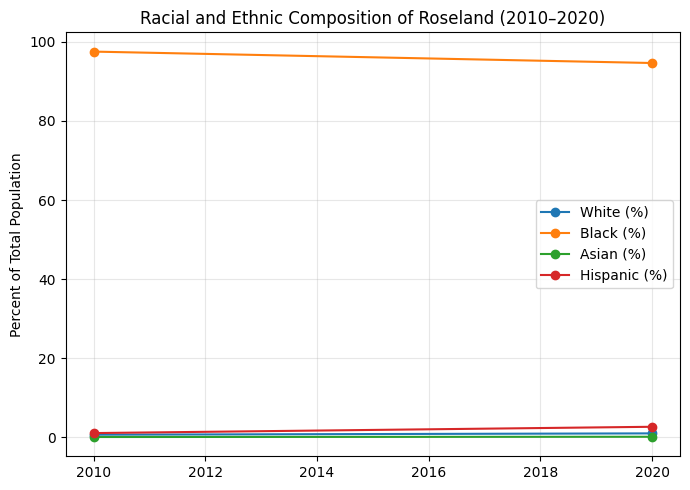

In [19]:
# Melt the data for grouped bar chart
race_data = agg_data.melt(id_vars="Year", value_vars=["White (%)", "Black (%)", "Asian (%)", "Hispanic (%)"])

plt.figure(figsize=(7, 5))
for race in ["White (%)", "Black (%)", "Asian (%)", "Hispanic (%)"]:
    subset = race_data[race_data["variable"] == race]
    plt.plot(subset["Year"], subset["value"], marker="o", label=race)

plt.title("Racial and Ethnic Composition of Roseland (2010–2020)")
plt.ylabel("Percent of Total Population")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Total population 2013 = 64,332
Total population 2023 = 60,464


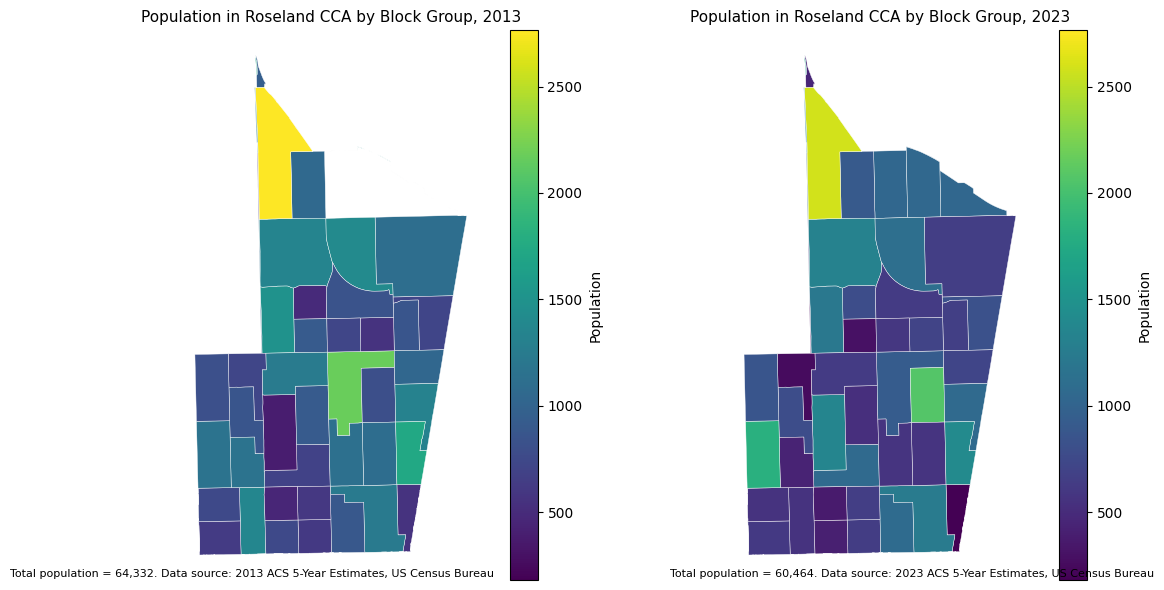

In [34]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------
# 1️⃣ Load canonical Roseland block groups
# -----------------------------------------------------
roseland_bg = bg_roseland.to_crs(4326)
roseland_bg['GEOID'] = roseland_bg['GEOID'].astype(str).str.zfill(12)

# -----------------------------------------------------
# 2️⃣ Load ACS data for all block groups (2010–2023)
# -----------------------------------------------------
df = pd.read_csv("Roseland-CA49/acs_blockgroups_all_years2010-2023.csv")
df['GEOID'] = df['GEOID'].astype(str).str.zfill(12)

# Filter for Roseland BGs
roseland_geoids = roseland_bg['GEOID'].unique().tolist()
df_roseland = df[df['GEOID'].isin(roseland_geoids)].copy()

# -----------------------------------------------------
# 3️⃣ Clean and select population variable
# -----------------------------------------------------
# B01003_001E = total population
df_roseland = df_roseland[['GEOID', 'year', 'B01003_001E']].rename(columns={'B01003_001E': 'population'})

# Keep only 2013 and 2023
df_roseland = df_roseland[df_roseland['year'].isin([2013, 2023])]

# Pivot so each BG has 2013 and 2023 side by side
pop_pivot = df_roseland.pivot(index='GEOID', columns='year', values='population').reset_index()
pop_pivot.columns = ['GEOID', 'pop_2013', 'pop_2023']

# Merge with geometry
gdf = roseland_bg.merge(pop_pivot, on='GEOID', how='left')

# -----------------------------------------------------
# 4️⃣ Compute total population and consistent scale
# -----------------------------------------------------
pop_2013_total = int(gdf['pop_2013'].sum(skipna=True))
pop_2023_total = int(gdf['pop_2023'].sum(skipna=True))

vmin = min(gdf[['pop_2013', 'pop_2023']].min())
vmax = max(gdf[['pop_2013', 'pop_2023']].max())

print(f"Total population 2013 = {pop_2013_total:,}")
print(f"Total population 2023 = {pop_2023_total:,}")

# -----------------------------------------------------
# 5️⃣ Plot comparison maps
# -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 2013
gdf.plot(column='pop_2013',
         cmap='viridis',
         linewidth=0.3,
         edgecolor='white',
         legend=True,
         legend_kwds={'label': "Population"},
         ax=axes[0],
         vmin=vmin, vmax=vmax)
axes[0].set_title("Population in Roseland CCA by Block Group, 2013", fontsize=11)
axes[0].axis("off")

# 2023
gdf.plot(column='pop_2023',
         cmap='viridis',
         linewidth=0.3,
         edgecolor='white',
         legend=True,
         legend_kwds={'label': "Population"},
         ax=axes[1],
         vmin=vmin, vmax=vmax)
axes[1].set_title("Population in Roseland CCA by Block Group, 2023", fontsize=11)
axes[1].axis("off")

plt.tight_layout()

# Captions
fig.text(0.22, 0.03,
         f"Total population = {pop_2013_total:,}. Data source: 2013 ACS 5-Year Estimates, US Census Bureau",
         ha='center', fontsize=8)
fig.text(0.77, 0.03,
         f"Total population = {pop_2023_total:,}. Data source: 2023 ACS 5-Year Estimates, US Census Bureau",
         ha='center', fontsize=8)

plt.show()
